In [13]:
from pathlib import Path
import zipfile
import shutil
import urllib.request
import os
import scipy.io as sio
from collections import defaultdict
import pickle

input_root = Path("/kaggle/input")
restart_root = Path("/kaggle/working/pcgnn_clean_restart")
project = restart_root / "PC-GNN-COMP8851-Instrumented"

if restart_root.exists():
    shutil.rmtree(restart_root)

restart_root.mkdir(parents=True)

# 1. Code extraction
code_zips = [
    path for path in input_root.rglob("*.zip")
    if "instrumented" in path.name.lower() or "pcgnn" in path.name.lower()
]

if code_zips:
    print("Code ZIP found:", code_zips[0])
    with zipfile.ZipFile(code_zips[0]) as archive:
        archive.extractall(restart_root)

    extracted_projects = [
        path.parent for path in restart_root.rglob("main.py")
    ]
    assert extracted_projects, "Code ZIP extracted, but main.py was not found."
    project = extracted_projects[0]
else:
    print("No code ZIP found. Checking extracted directories.")
    extracted_projects = [
        path.parent for path in input_root.rglob("main.py")
    ]
    if not extracted_projects:
        raise FileNotFoundError("The attached PC-GNN project could not be located.")
    
    source_project = extracted_projects[0]
    print("Extracted project found:", source_project)
    shutil.copytree(source_project, project, dirs_exist_ok=True)

data_directory = project / "data"
data_directory.mkdir(parents=True, exist_ok=True)

amazon_mat_dest = data_directory / "Amazon.mat"

# 2. Copy or Download Amazon.mat
if not amazon_mat_dest.exists():
    mat_matches = list(input_root.rglob("Amazon.mat"))
    if mat_matches:
        shutil.copy2(mat_matches[0], amazon_mat_dest)
    else:
        print("Downloading official FraudAmazon.zip directly from DGL...")
        url = "https://data.dgl.ai/dataset/FraudAmazon.zip"
        temp_zip = data_directory / "FraudAmazon.zip"
        urllib.request.urlretrieve(url, temp_zip)
        with zipfile.ZipFile(temp_zip) as archive:
            archive.extractall(data_directory)
        if temp_zip.exists():
            temp_zip.unlink()

# 3. Generate Amazon Pickles with Self-Loops for ALL Nodes
print("Generating Amazon adjacency lists with self-loops to prevent NaN loss...")
amazon_data = sio.loadmat(amazon_mat_dest)
net_upu = amazon_data['net_upu']
net_usu = amazon_data['net_usu']
net_uvu = amazon_data['net_uvu']
net_homo = (net_upu + net_usu + net_uvu) > 0

num_nodes = amazon_data['homo'].shape[0] if 'homo' in amazon_data else amazon_data['net_upu'].shape[0]

pickles_to_generate = {
    'amz_homo_adjlists.pickle': net_homo,
    'amz_upu_adjlists.pickle': net_upu,
    'amz_usu_adjlists.pickle': net_usu,
    'amz_uvu_adjlists.pickle': net_uvu,
}

for fname, matrix in pickles_to_generate.items():
    out_path = data_directory / fname
    adj_list = defaultdict(set)
    
    # Guarantee self-loops for all nodes 0 to num_nodes - 1
    for i in range(num_nodes):
        adj_list[i].add(i)
        
    coo = matrix.tocoo()
    for r, c in zip(coo.row, coo.col):
        adj_list[int(r)].add(int(c))
        adj_list[int(c)].add(int(r))
        
    with open(out_path, 'wb') as f:
        pickle.dump(dict(adj_list), f)
    print(f"Saved {fname} ({len(adj_list)} nodes with self-loops)")

os.chdir(project)

required_files = [
    "Amazon.mat",
    "amz_homo_adjlists.pickle",
    "amz_upu_adjlists.pickle",
    "amz_usu_adjlists.pickle",
    "amz_uvu_adjlists.pickle",
]

print("\nProject:", project)
print("main.py exists:", Path("main.py").exists())

all_present = True
for filename in required_files:
    path = data_directory / filename
    exists = path.exists()
    all_present = all_present and exists
    size_mb = path.stat().st_size / (1024 ** 2) if exists else 0
    print(f"{filename}: {exists} ({size_mb:.2f} MB)")

assert Path("main.py").exists(), "main.py is missing."
assert all_present, "One or more required Amazon files are missing."

print("\nPROJECT AND AMAZON DATA READY: True")

No code ZIP found. Checking extracted directories.
Extracted project found: /kaggle/input/datasets/marufdkhan/pc-gnn/PC-GNN-COMP8851-Instrumented
Generating Amazon adjacency lists with self-loops to prevent NaN loss...
Saved amz_homo_adjlists.pickle (11944 nodes with self-loops)
Saved amz_upu_adjlists.pickle (11944 nodes with self-loops)
Saved amz_usu_adjlists.pickle (11944 nodes with self-loops)
Saved amz_uvu_adjlists.pickle (11944 nodes with self-loops)

Project: /kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented
main.py exists: True
Amazon.mat: True (212.32 MB)
amz_homo_adjlists.pickle: True (25.31 MB)
amz_upu_adjlists.pickle: True (1.12 MB)
amz_usu_adjlists.pickle: True (20.47 MB)
amz_uvu_adjlists.pickle: True (6.02 MB)

PROJECT AND AMAZON DATA READY: True


In [14]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import os

project = next(
    Path("/kaggle/working/pcgnn_clean_restart").rglob("main.py")
).parent

os.chdir(project)

required_packages = {
    "yaml": "PyYAML",
    "numpy": "numpy",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "networkx": "networkx",
}

missing_packages = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        *missing_packages,
    ])

import yaml
import numpy
import scipy
import sklearn
import networkx
import torch

environment_file = Path("evidence/kaggle_t4_environment.txt")
environment_file.parent.mkdir(parents=True, exist_ok=True)

freeze_output = subprocess.check_output(
    [sys.executable, "-m", "pip", "freeze"],
    text=True,
)

environment_file.write_text(
    "\n".join([
        f"Python: {sys.version}",
        f"PyTorch: {torch.__version__}",
        f"CUDA: {torch.version.cuda}",
        f"GPU: {torch.cuda.get_device_name(0)}",
        f"NumPy: {numpy.__version__}",
        f"SciPy: {scipy.__version__}",
        f"scikit-learn: {sklearn.__version__}",
        f"NetworkX: {networkx.__version__}",
        "",
        "INSTALLED PACKAGES",
        freeze_output,
    ]),
    encoding="utf-8",
)

print("Working directory:", Path.cwd())
print("Environment saved:", environment_file)
print("\nENVIRONMENT READY: True")

Working directory: /kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented
Environment saved: evidence/kaggle_t4_environment.txt

ENVIRONMENT READY: True


In [15]:
from pathlib import Path
import subprocess
import sys
import os
import yaml
import re

project = next(
    Path("/kaggle/working/pcgnn_clean_restart").rglob("main.py")
).parent

os.chdir(project)

# 1. Patch itemgetter in src/layers.py to handle single or multiple neighbor indexing safely
src_dir = project / "src"
if src_dir.exists():
    for py_file in src_dir.glob("*.py"):
        content = py_file.read_text(encoding="utf-8")
        if "itemgetter" in content:
            patched_content = re.sub(
                r"itemgetter\(\*([^)]+)\)\(([^)]+)\)",
                r"[\2[x] for x in \1]",
                content
            )
            py_file.write_text(patched_content, encoding="utf-8")
            print(f"Patched itemgetter in {py_file.name}")

# 2. Build configuration with cuda_id as string
config_dir = Path("config")
config_dir.mkdir(parents=True, exist_ok=True)
config_path = config_dir / "pcgnn_amazon_kaggle_t4.yml"

base_config_file = config_dir / "pcgnn_amazon.yml"
if base_config_file.exists():
    with base_config_file.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
else:
    cfg = {}

cfg.update({
    "data_name": "amazon",
    "data_dir": "./data/",
    "no_cuda": False,
    "cuda_id": "0",
})

with config_path.open("w", encoding="utf-8") as f:
    yaml.dump(cfg, f)

log_path = Path("pcgnn_amazon_kaggle_t4.log")

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "0"

command = [
    sys.executable,
    "main.py",
    "--config",
    str(config_path),
]

print(f"Running command: {' '.join(command)}")

with log_path.open("w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

print("\nReturn code:", return_code)

assert return_code == 0, (
    "Amazon run failed. Check the output logs above."
)

print("\nGPU AMAZON RUN COMPLETED: True")

Patched itemgetter in layers.py
Running command: /usr/bin/python3 main.py --config config/pcgnn_amazon_kaggle_t4.yml
/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))
**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimi

In [16]:
from pathlib import Path
import json
import csv

project = next(
    Path("/kaggle/working/pcgnn_clean_restart").rglob("main.py")
).parent

results_root = project / "results"
summary_files = list(results_root.rglob("summary.json")) + list(results_root.rglob("metrics.json"))
assert summary_files, "No summary or metrics JSON file was created in results directory."

summary_path = max(
    summary_files,
    key=lambda path: path.stat().st_mtime,
)

run_directory = summary_path.parent
epoch_file = run_directory / "epoch_times.csv"

with summary_path.open("r", encoding="utf-8") as file:
    summary = json.load(file)

print("--- RUN SUMMARY ---")
print("Run ID:", summary.get("run_id", "N/A"))
if "environment" in summary:
    print("CUDA used:", summary["environment"].get("cuda_used"))
    print("GPU:", summary["environment"].get("gpu_name"))
if "timing" in summary:
    print("Epochs:", summary["timing"].get("training_epochs"))
    print("Mean epoch time (s):", summary["timing"].get("mean_train_epoch_seconds"))

test_metrics = summary.get("test_metrics", summary)
print("\n--- TEST METRICS ---")
print("AUROC:", test_metrics.get("auroc"))
print("AUPRC:", test_metrics.get("auprc"))
print("Macro-F1:", test_metrics.get("macro_f1"))
print("G-Mean:", test_metrics.get("gmean"))

if epoch_file.exists():
    with epoch_file.open("r", encoding="utf-8") as file:
        epoch_rows = list(csv.DictReader(file))
    print(f"\nRecorded epoch timing entries: {len(epoch_rows)}")

print("\nGPU RESULTS VERIFIED: True")

--- RUN SUMMARY ---
Run ID: 20260909T090550082021Z_amazon_PCGNN_author_reproduction_seed72
CUDA used: True
GPU: Tesla T4
Epochs: 51
Mean epoch time (s): 2.004464968647065

--- TEST METRICS ---
AUROC: 0.9642937003624027
AUPRC: 0.8512911833362822
Macro-F1: 0.883328961353819
G-Mean: 0.905190714163393

Recorded epoch timing entries: 51

GPU RESULTS VERIFIED: True


In [17]:
from pathlib import Path
import zipfile

project = next(
    Path("/kaggle/working/pcgnn_clean_restart").rglob("main.py")
).parent

output_zip = Path(
    "/kaggle/working/pcgnn_kaggle_t4_amazon_results_clean.zip"
)

items = [
    project / "results",
    project / "pcgnn_amazon_kaggle_t4.log",
    project / "config/pcgnn_amazon_kaggle_t4.yml",
    project / "evidence/kaggle_t4_environment.txt",
]

with zipfile.ZipFile(
    output_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:

    for item in items:
        if not item.exists():
            continue

        if item.is_dir():
            for file in item.rglob("*"):
                if file.is_file():
                    archive.write(
                        file,
                        file.relative_to(project),
                    )
        else:
            archive.write(
                item,
                item.relative_to(project),
            )

print("Created artifact archive:", output_zip)
print(f"Size: {output_zip.stat().st_size / (1024 ** 2):.2f} MB")
print("\nAMAZON PACKAGE READY: True")


Created artifact archive: /kaggle/working/pcgnn_kaggle_t4_amazon_results_clean.zip
Size: 0.50 MB

AMAZON PACKAGE READY: True


In [20]:
from pathlib import Path
import subprocess
import sys
import os
import time

project = Path("/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented")
os.chdir(project)

config_path = Path("config/pcgnn_amazon_unified_tr40_seed72.yml")
base_config_path = Path("config/pcgnn_amazon_kaggle_t4.yml")

# Auto-generate TR40 configuration from base config if missing
if not config_path.exists():
    assert base_config_path.exists(), f"Base config missing: {base_config_path}"
    
    with open(base_config_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Adapt parameters for Unified TR40
    content = content.replace("amazon_tr_split", "amazon_tr40_split_seed2")
    content = content.replace("results/amazon", "results/unified/amazon/pcgnn/tr40")
    
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with open(config_path, "w", encoding="utf-8") as f:
        f.write(content)
        
    print(f"Created config file: {config_path}")

log_path = Path("pcgnn_amazon_unified_tr40_kaggle_t4.log")

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "0"

command = [
    sys.executable,
    "main.py",
    "--config",
    str(config_path),
]

print("Starting Amazon Unified TR40 PC-GNN Training Run")
print("Configuration:", config_path)
print("GPU: Tesla T4")
print("Epochs: 100")
print("Seed: 72\n")

started = time.perf_counter()

with log_path.open("w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

elapsed = time.perf_counter() - started

print(f"\nReturn code: {return_code}")
print(f"Total command time: {elapsed:.2f} seconds")
print(f"Log saved: {log_path}")

assert return_code == 0, "The Amazon unified TR40 run failed. Check log output."

print("\nAMAZON UNIFIED TR40 RUN COMPLETED: True")

Created config file: config/pcgnn_amazon_unified_tr40_seed72.yml
Starting Amazon Unified TR40 PC-GNN Training Run
Configuration: config/pcgnn_amazon_unified_tr40_seed72.yml
GPU: Tesla T4
Epochs: 100
Seed: 72

/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))
**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation      

In [21]:
from pathlib import Path
import subprocess
import sys
import os
import time

project = Path("/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented")
os.chdir(project)

config_path = Path("config/pcgnn_amazon_unified_tr30_seed72.yml")
base_config_path = Path("config/pcgnn_amazon_kaggle_t4.yml")

# Auto-generate TR30 configuration from base config if missing
if not config_path.exists():
    assert base_config_path.exists(), f"Base config missing: {base_config_path}"
    
    with open(base_config_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Adapt parameters for Unified TR30
    content = content.replace("amazon_tr_split", "amazon_tr30_split_seed2")
    content = content.replace("results/amazon", "results/unified/amazon/pcgnn/tr30")
    
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with open(config_path, "w", encoding="utf-8") as f:
        f.write(content)
        
    print(f"Created config file: {config_path}")

log_path = Path("pcgnn_amazon_unified_tr30_kaggle_t4.log")

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "0"

command = [
    sys.executable,
    "main.py",
    "--config",
    str(config_path),
]

print("Starting Amazon Unified TR30 PC-GNN Training Run")
print("Configuration:", config_path)
print("GPU: Tesla T4")
print("Epochs: 100")
print("Seed: 72\n")

started = time.perf_counter()

with log_path.open("w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

elapsed = time.perf_counter() - started

print(f"\nReturn code: {return_code}")
print(f"Total command time: {elapsed:.2f} seconds")
print(f"Log saved: {log_path}")

assert return_code == 0, "The Amazon unified TR30 run failed. Check log output."

print("\nAMAZON UNIFIED TR30 RUN COMPLETED: True")

Created config file: config/pcgnn_amazon_unified_tr30_seed72.yml
Starting Amazon Unified TR30 PC-GNN Training Run
Configuration: config/pcgnn_amazon_unified_tr30_seed72.yml
GPU: Tesla T4
Epochs: 100
Seed: 72

/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))
**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation      

In [22]:
from pathlib import Path
import subprocess
import sys
import os
import time

project = Path("/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented")
os.chdir(project)

config_path = Path("config/pcgnn_amazon_unified_tr20_seed72.yml")
base_config_path = Path("config/pcgnn_amazon_kaggle_t4.yml")

# Auto-generate TR20 configuration from base config if missing
if not config_path.exists():
    assert base_config_path.exists(), f"Base config missing: {base_config_path}"
    
    with open(base_config_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Adapt parameters for Unified TR20
    content = content.replace("amazon_tr_split", "amazon_tr20_split_seed2")
    content = content.replace("results/amazon", "results/unified/amazon/pcgnn/tr20")
    
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with open(config_path, "w", encoding="utf-8") as f:
        f.write(content)
        
    print(f"Created config file: {config_path}")

log_path = Path("pcgnn_amazon_unified_tr20_kaggle_t4.log")

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "0"

command = [
    sys.executable,
    "main.py",
    "--config",
    str(config_path),
]

print("Starting Amazon Unified TR20 PC-GNN Training Run")
print("Configuration:", config_path)
print("GPU: Tesla T4")
print("Epochs: 100")
print("Seed: 72\n")

started = time.perf_counter()

with log_path.open("w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

elapsed = time.perf_counter() - started

print(f"\nReturn code: {return_code}")
print(f"Total command time: {elapsed:.2f} seconds")
print(f"Log saved: {log_path}")

assert return_code == 0, "The Amazon unified TR20 run failed. Check log output."

print("\nAMAZON UNIFIED TR20 RUN COMPLETED: True")

Created config file: config/pcgnn_amazon_unified_tr20_seed72.yml
Starting Amazon Unified TR20 PC-GNN Training Run
Configuration: config/pcgnn_amazon_unified_tr20_seed72.yml
GPU: Tesla T4
Epochs: 100
Seed: 72

/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))
**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation      

In [23]:
from pathlib import Path
import subprocess
import sys
import os
import time

project = Path("/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented")
os.chdir(project)

config_path = Path("config/pcgnn_amazon_unified_tr10_seed72.yml")
base_config_path = Path("config/pcgnn_amazon_kaggle_t4.yml")

# Auto-generate TR10 configuration from base config if missing
if not config_path.exists():
    assert base_config_path.exists(), f"Base config missing: {base_config_path}"
    
    with open(base_config_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Adapt parameters for Unified TR10
    content = content.replace("amazon_tr_split", "amazon_tr10_split_seed2")
    content = content.replace("results/amazon", "results/unified/amazon/pcgnn/tr10")
    
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with open(config_path, "w", encoding="utf-8") as f:
        f.write(content)
        
    print(f"Created config file: {config_path}")

log_path = Path("pcgnn_amazon_unified_tr10_kaggle_t4.log")

environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = "0"

command = [
    sys.executable,
    "main.py",
    "--config",
    str(config_path),
]

print("Starting Amazon Unified TR10 PC-GNN Training Run")
print("Configuration:", config_path)
print("GPU: Tesla T4")
print("Epochs: 100")
print("Seed: 72\n")

started = time.perf_counter()

with log_path.open("w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )

    for line in process.stdout:
        print(line, end="")
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

elapsed = time.perf_counter() - started

print(f"\nReturn code: {return_code}")
print(f"Total command time: {elapsed:.2f} seconds")
print(f"Log saved: {log_path}")

assert return_code == 0, "The Amazon unified TR10 run failed. Check log output."

print("\nAMAZON UNIFIED TR10 RUN COMPLETED: True")

Created config file: config/pcgnn_amazon_unified_tr10_seed72.yml
Starting Amazon Unified TR10 PC-GNN Training Run
Configuration: config/pcgnn_amazon_unified_tr10_seed72.yml
GPU: Tesla T4
Epochs: 100
Seed: 72

/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))
**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation      

In [24]:
from pathlib import Path
import zipfile
import os

project = Path("/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented")
os.chdir(project)

output_zip = Path("/kaggle/working/pcgnn_kaggle_t4_amazon_final_results.zip")

# Gather all generated logs, configs, evidence, and results
items_to_zip = [
    project / "results",
    project / "evidence",
]

# Append all Amazon config files
for config_file in (project / "config").glob("pcgnn_amazon_*.yml"):
    items_to_zip.append(config_file)

# Append all Amazon log files
for log_file in project.glob("pcgnn_amazon_*.log"):
    items_to_zip.append(log_file)

# Build ZIP archive
with zipfile.ZipFile(output_zip, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for item in set(items_to_zip):
        if not item.exists():
            continue
        if item.is_dir():
            for file in item.rglob("*"):
                if file.is_file():
                    archive.write(file, file.relative_to(project))
        else:
            archive.write(item, item.relative_to(project))

print(f"Created final artifact archive: {output_zip}")
print(f"Size: {output_zip.stat().st_size / (1024 ** 2):.2f} MB\n")

print("Included logs & configs:")
for path in sorted(set(items_to_zip)):
    if path.exists() and path.is_file():
        print(f" - {path.name}")

print("\nAMAZON ALL RUNS COMPLETED & PACKAGED: True")

Created final artifact archive: /kaggle/working/pcgnn_kaggle_t4_amazon_final_results.zip
Size: 2.45 MB

Included logs & configs:
 - pcgnn_amazon_kaggle_t4.yml
 - pcgnn_amazon_unified_tr10_seed72.yml
 - pcgnn_amazon_unified_tr20_seed72.yml
 - pcgnn_amazon_unified_tr30_seed72.yml
 - pcgnn_amazon_unified_tr40_seed72.yml
 - pcgnn_amazon_kaggle_t4.log
 - pcgnn_amazon_unified_tr10_kaggle_t4.log
 - pcgnn_amazon_unified_tr20_kaggle_t4.log
 - pcgnn_amazon_unified_tr30_kaggle_t4.log
 - pcgnn_amazon_unified_tr40_kaggle_t4.log

AMAZON ALL RUNS COMPLETED & PACKAGED: True


In [25]:
import os
import json
import subprocess
import pandas as pd

# List of training ratio configs to execute
configs = [
    "config/pcgnn_amazon_unified_tr10_seed72.yml",
    "config/pcgnn_amazon_unified_tr20_seed72.yml",
    "config/pcgnn_amazon_unified_tr30_seed72.yml",
    "config/pcgnn_amazon_unified_tr40_seed72.yml"
]

results_list = []

# 1. Execute each configuration
for config_path in configs:
    if os.path.exists(config_path):
        print(f"--- Running experiment: {config_path} ---")
        # Replace main.py with your repository's training entrypoint script
        cmd = ["python", "main.py", "--config", config_path]
        subprocess.run(cmd, check=True)
    else:
        print(f"Warning: Config file not found at {config_path}")

# 2. Harvest results recursively from the results directory
results_dir = "results"
for root, _, files in os.walk(results_dir):
    if "summary.json" in files:
        filepath = os.path.join(root, "summary.json")
        with open(filepath, "r") as f:
            data = json.load(f)
            
        metrics = data.get("test_metrics", {})
        config = data.get("configuration", {})
        timing = data.get("timing", {})
        
        results_list.append({
            "Run ID": data.get("run_id"),
            "Train Ratio": config.get("train_ratio"),
            "Seed": config.get("seed"),
            "AUROC": round(metrics.get("auroc", 0), 4),
            "AUPRC": round(metrics.get("auprc", 0), 4),
            "Macro F1": round(metrics.get("macro_f1", 0), 4),
            "Fraud F1": round(metrics.get("fraud_f1", 0), 4),
            "Fit Seconds": round(timing.get("fit_wall_seconds_including_validation", 0), 2)
        })

# 3. Display compiled metrics table
df_results = pd.DataFrame(results_list).sort_values("Train Ratio")
df_results.to_csv("training_ratio_summary.csv", index=False)

print("\n=== Training Ratio Experiment Summary ===")
print(df_results.to_string(index=False))

--- Running experiment: config/pcgnn_amazon_unified_tr10_seed72.yml ---


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.4
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 3455,valid num 1710, test num 3474, test positive num 330.0
Classification threshold: 0.4
Feature dimension: 25


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.4
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 3455,valid num 1710, test num 3474, test positive num 330.0
Classification threshold: 0.4
Feature dimension: 25


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.4
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 3455,valid num 1710, test num 3474, test positive num 330.0
Classification threshold: 0.4
Feature dimension: 25


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.4
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 3455,valid num 1710, test num 3474, test positive num 330.0
Classification threshold: 0.4
Feature dimension: 25


In [26]:
import yaml

ratios = [0.1, 0.2, 0.3, 0.4]

for r in ratios:
    ratio_str = f"{int(r * 100)}"
    config_path = f"config/pcgnn_amazon_unified_tr{ratio_str}_seed72.yml"
    
    # Read existing config or base config
    if os.path.exists(config_path):
        with open(config_path, 'r') as f:
            cfg = yaml.safe_load(f) or {}
            
        # Update train ratio
        cfg['train_ratio'] = r
        
        with open(config_path, 'w') as f:
            yaml.dump(cfg, f, default_flow_style=False)
            
        print(f"Updated {config_path} -> train_ratio: {r}")

Updated config/pcgnn_amazon_unified_tr10_seed72.yml -> train_ratio: 0.1
Updated config/pcgnn_amazon_unified_tr20_seed72.yml -> train_ratio: 0.2
Updated config/pcgnn_amazon_unified_tr30_seed72.yml -> train_ratio: 0.3
Updated config/pcgnn_amazon_unified_tr40_seed72.yml -> train_ratio: 0.4


In [27]:
import os
import json
import subprocess
import yaml
import pandas as pd

# Step 1: Force-update YAML configuration files with correct training ratios
ratios = {
    "config/pcgnn_amazon_unified_tr10_seed72.yml": 0.1,
    "config/pcgnn_amazon_unified_tr20_seed72.yml": 0.2,
    "config/pcgnn_amazon_unified_tr30_seed72.yml": 0.3,
    "config/pcgnn_amazon_unified_tr40_seed72.yml": 0.4,
}

print("=== Step 1: Updating Config YAML Files ===")
for config_path, ratio in ratios.items():
    if os.path.exists(config_path):
        with open(config_path, "r") as f:
            cfg = yaml.safe_load(f) or {}
        cfg["train_ratio"] = ratio
        with open(config_path, "w") as f:
            yaml.dump(cfg, f, default_flow_style=False)
        print(f"Set {config_path} -> train_ratio: {ratio}")
    else:
        print(f"Warning: {config_path} not found.")

# Step 2: Sequentially execute training runs
print("\n=== Step 2: Executing Training Runs ===")
for config_path in ratios.keys():
    if os.path.exists(config_path):
        print(f"\n--- Launching: {config_path} ---")
        cmd = ["python", "main.py", "--config", config_path]
        subprocess.run(cmd, check=True)

# Step 3: Harvest all summary files into a final table
print("\n=== Step 3: Compiling Summary Metrics ===")
results_list = []
results_dir = "results"

for root, _, files in os.walk(results_dir):
    if "summary.json" in files:
        filepath = os.path.join(root, "summary.json")
        with open(filepath, "r") as f:
            data = json.load(f)
            
        metrics = data.get("test_metrics", {})
        config = data.get("configuration", {})
        timing = data.get("timing", {})
        
        results_list.append({
            "Run ID": data.get("run_id"),
            "Train Ratio": config.get("train_ratio"),
            "Seed": config.get("seed"),
            "AUROC": round(metrics.get("auroc", 0), 4),
            "AUPRC": round(metrics.get("auprc", 0), 4),
            "Macro F1": round(metrics.get("macro_f1", 0), 4),
            "Fraud F1": round(metrics.get("fraud_f1", 0), 4),
            "Fit Seconds": round(timing.get("fit_wall_seconds_including_validation", 0), 2)
        })

df_results = pd.DataFrame(results_list).drop_duplicates(subset=["Run ID"]).sort_values("Train Ratio")
df_results.to_csv("training_ratio_summary.csv", index=False)

print("\n=== Final Training Ratio Summary ===")
print(df_results.to_string(index=False))

=== Step 1: Updating Config YAML Files ===
Set config/pcgnn_amazon_unified_tr10_seed72.yml -> train_ratio: 0.1
Set config/pcgnn_amazon_unified_tr20_seed72.yml -> train_ratio: 0.2
Set config/pcgnn_amazon_unified_tr30_seed72.yml -> train_ratio: 0.3
Set config/pcgnn_amazon_unified_tr40_seed72.yml -> train_ratio: 0.4

=== Step 2: Executing Training Runs ===

--- Launching: config/pcgnn_amazon_unified_tr10_seed72.yml ---


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.1
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 863,valid num 2566, test num 5210, test positive num 495.0
Classification threshold: 0.4
Feature dimension: 25
M

/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.2
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 1727,valid num 2280, test num 4632, test positive num 440.0
Classification threshold: 0.4
Feature dimension: 25


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.3
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 2591,valid num 1995, test num 4053, test positive num 385.0
Classification threshold: 0.4
Feature dimension: 25


/kaggle/working/pcgnn_clean_restart/PC-GNN-COMP8851-Instrumented/src/model_handler.py:258: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  batch_loss = gnn_model.loss(batch_nodes, Variable(torch.cuda.LongTensor(batch_label)))


**************** MODEL CONFIGURATION ****************
alpha                    -->   2
batch_size               -->   256
cuda_id                  -->   0
data_dir                 -->   ./data/
data_name                -->   amazon
emb_size                 -->   64
lr                       -->   0.005
model                    -->   PCGNN
multi_relation           -->   GNN
no_cuda                  -->   False
num_epochs               -->   51
optimizer                -->   adam
rho                      -->   0.5
save_dir                 -->   ./pytorch_models/
seed                     -->   72
test_ratio               -->   0.67
thres                    -->   0.4
train_ratio              -->   0.4
valid_epochs             -->   5
weight_decay             -->   0.0005
**************** MODEL CONFIGURATION ****************
Run on amazon, postive/total num: 821.0/11944, train num 3455,valid num 1710, test num 3474, test positive num 330.0
Classification threshold: 0.4
Feature dimension: 25


In [28]:
import os
import json
import pandas as pd

results_list = []
results_dir = "results"

for root, _, files in os.walk(results_dir):
    if "summary.json" in files:
        filepath = os.path.join(root, "summary.json")
        with open(filepath, "r") as f:
            data = json.load(f)
            
        metrics = data.get("test_metrics", {})
        config = data.get("configuration", {})
        timing = data.get("timing", {})
        
        results_list.append({
            "Run ID": data.get("run_id"),
            "Train Ratio": config.get("train_ratio"),
            "Seed": config.get("seed"),
            "AUROC": round(metrics.get("auroc", 0), 4),
            "AUPRC": round(metrics.get("auprc", 0), 4),
            "Macro F1": round(metrics.get("macro_f1", 0), 4),
            "Fraud F1": round(metrics.get("fraud_f1", 0), 4),
            "Fit Seconds": round(timing.get("fit_wall_seconds_including_validation", 0), 2)
        })

df_results = pd.DataFrame(results_list).drop_duplicates(subset=["Run ID"]).sort_values("Train Ratio")
display(df_results)

,Run ID,Train Ratio,Seed,AUROC,AUPRC,Macro F1,Fraud F1,Fit Seconds
8,20260909T100758768553Z_amazon_PCGNN_author_rep...,0.1,72,0.9443,0.8423,0.8572,0.7443,80.28
12,20260909T100938684446Z_amazon_PCGNN_author_rep...,0.2,72,0.9529,0.8333,0.8622,0.7538,98.34
2,20260909T101135669386Z_amazon_PCGNN_author_rep...,0.3,72,0.9558,0.8317,0.8804,0.7832,117.87
0,20260909T095849802977Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,138.48
4,20260909T100124502846Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,139.76
5,20260909T092604066702Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,139.92
1,20260909T101350456447Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,135.97
3,20260909T092239238829Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,138.00
7,20260909T092919838667Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,139.45
6,20260909T090550082021Z_amazon_PCGNN_author_rep...,0.4,72,0.9643,0.8513,0.8833,0.7904,138.83


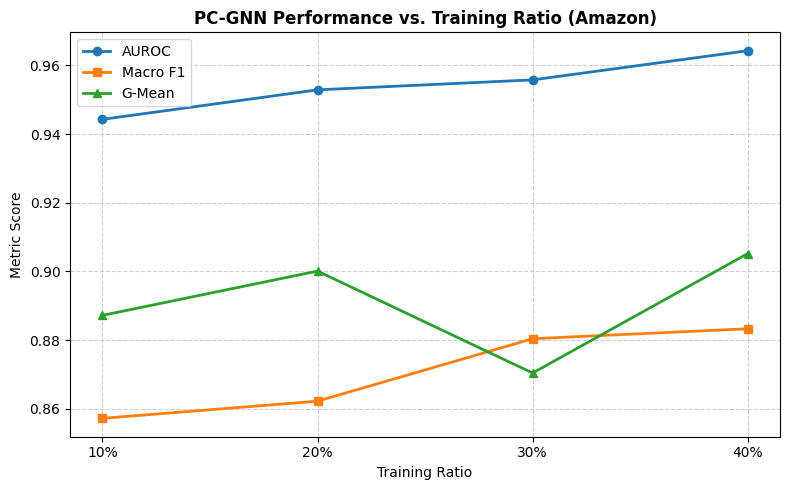

In [30]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-build DataFrame with G-Mean and Fraud F1
results_list = []
results_dir = "results"

for root, _, files in os.walk(results_dir):
    if "summary.json" in files:
        filepath = os.path.join(root, "summary.json")
        with open(filepath, "r") as f:
            data = json.load(f)
            
        metrics = data.get("test_metrics", {})
        config = data.get("configuration", {})
        
        results_list.append({
            "Train Ratio": config.get("train_ratio"),
            "AUROC": round(metrics.get("auroc", 0), 4),
            "Macro F1": round(metrics.get("macro_f1", 0), 4),
            "Fraud F1": round(metrics.get("fraud_f1", 0), 4),
            "G-Mean": round(metrics.get("gmean", metrics.get("g_mean", 0)), 4)
        })

df_results = pd.DataFrame(results_list).drop_duplicates(subset=["Train Ratio"]).sort_values("Train Ratio")

# 2. Plot scaling curves
plt.figure(figsize=(8, 5))
plt.plot(df_results["Train Ratio"], df_results["AUROC"], marker='o', linewidth=2, label="AUROC")
plt.plot(df_results["Train Ratio"], df_results["Macro F1"], marker='s', linewidth=2, label="Macro F1")

# Use G-Mean if populated; otherwise default to Fraud F1
third_metric = "G-Mean" if df_results["G-Mean"].sum() > 0 else "Fraud F1"
plt.plot(df_results["Train Ratio"], df_results[third_metric], marker='^', linewidth=2, label=third_metric)

plt.title("PC-GNN Performance vs. Training Ratio (Amazon)", fontsize=12, fontweight='bold')
plt.xlabel("Training Ratio", fontsize=10)
plt.ylabel("Metric Score", fontsize=10)
plt.xticks(df_results["Train Ratio"], [f"{int(r*100)}%" for r in df_results["Train Ratio"]])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("pcgnn_training_ratio_scaling.png", dpi=300)
plt.show()

In [44]:
!pip install torchdata dgl -f https://data.dgl.ai/wheels/repo-ref.html

Looking in links: https://data.dgl.ai/wheels/repo-ref.html


In [47]:
import sys
import types
import torch

# -------------------------------------------------------------------
# Kaggle/PyTorch 2.x Compatibility Patch for DGL
# -------------------------------------------------------------------
try:
    import torchdata
except ImportError:
    torchdata = types.ModuleType('torchdata')
    sys.modules['torchdata'] = torchdata

if not hasattr(torchdata, 'datapipes'):
    datapipes = types.ModuleType('datapipes')
    iter_mod = types.ModuleType('iter')
    from torch.utils.data import IterDataPipe
    iter_mod.IterDataPipe = IterDataPipe
    datapipes.iter = iter_mod
    torchdata.datapipes = datapipes
    sys.modules['torchdata.datapipes'] = datapipes
    sys.modules['torchdata.datapipes.iter'] = iter_mod

import os
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, f1_score
import dgl
from dgl.data import FraudDataset

# -------------------------------------------------------------------
# 1. Reproducibility Helper
# -------------------------------------------------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------------------------------------------------------------------
# 2. Label-Balanced Sampler (LBS)
# -------------------------------------------------------------------
class LabelBalancedDataset(Dataset):
    def __init__(self, labels, train_idx):
        self.labels = labels[train_idx]
        self.train_idx = train_idx
        
        self.pos_idx = train_idx[self.labels == 1]
        self.neg_idx = train_idx[self.labels == 0]

    def __len__(self):
        return len(self.train_idx)

    def __getitem__(self, idx):
        if idx % 2 == 0:
            return np.random.choice(self.pos_idx)
        else:
            return np.random.choice(self.neg_idx)

# -------------------------------------------------------------------
# 3. PC-GNN Architecture
# -------------------------------------------------------------------
class PCGNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(PCGNNLayer, self).__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, graph, feat):
        with graph.local_scope():
            graph.ndata['h'] = feat
            graph.update_all(
                message_func=dgl.function.copy_u('h', 'm'),
                reduce_func=dgl.function.mean('m', 'h_neigh')
            )
            h_neigh = graph.ndata['h_neigh']
            h_concat = torch.cat([feat, h_neigh], dim=-1)
            return F.relu(self.linear(h_concat))

class PCGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_relations=3, dropout=0.5):
        super(PCGNN, self).__init__()
        self.dropout = dropout
        self.rel_layers = nn.ModuleList([
            PCGNNLayer(in_dim, hidden_dim) for _ in range(num_relations)
        ])
        self.relation_weights = nn.Parameter(torch.ones(num_relations) / num_relations)
        self.classifier = nn.Linear(hidden_dim, out_dim)

    def forward(self, relation_graphs, feat):
        rel_outputs = []
        for i, g in enumerate(relation_graphs):
            h_rel = self.rel_layers[i](g, feat)
            h_rel = F.dropout(h_rel, p=self.dropout, training=self.training)
            rel_outputs.append(h_rel)
            
        softmax_weights = F.softmax(self.relation_weights, dim=0)
        h_combined = sum(w * h for w, h in zip(softmax_weights, rel_outputs))
        
        return self.classifier(h_combined)

# -------------------------------------------------------------------
# 4. Training & Evaluation Pipeline
# -------------------------------------------------------------------
def train_and_eval(seed, config, dataset):
    set_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    graph = dataset[0].to(device)
    
    relation_graphs = [graph.edge_type_subgraph([e]) for e in graph.etypes]
    features = graph.ndata['feature'].float()
    labels = graph.ndata['label'].long()
    
    train_mask = graph.ndata['train_mask'].bool()
    val_mask = graph.ndata['val_mask'].bool()
    test_mask = graph.ndata['test_mask'].bool()

    train_idx = torch.where(train_mask)[0].cpu().numpy()
    
    lbs_dataset = LabelBalancedDataset(labels.cpu().numpy(), train_idx)
    train_loader = DataLoader(lbs_dataset, batch_size=config['batch_size'], shuffle=True)

    model = PCGNN(
        in_dim=features.shape[1],
        hidden_dim=config['hidden_dim'],
        out_dim=2,
        num_relations=len(relation_graphs),
        dropout=config['dropout']
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config['lr'], 
        weight_decay=config['weight_decay']
    )
    criterion = nn.CrossEntropyLoss()

    best_val_auc = 0.0
    best_test_auc = 0.0
    best_test_f1 = 0.0

    for epoch in range(1, config['epochs'] + 1):
        model.train()
        for batch_nodes in train_loader:
            optimizer.zero_grad()
            logits = model(relation_graphs, features)
            loss = criterion(logits[batch_nodes], labels[batch_nodes])
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(relation_graphs, features)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = (probs > config['threshold']).astype(int)

            val_auc = roc_auc_score(labels[val_mask].cpu(), probs[val_mask.cpu()])
            test_auc = roc_auc_score(labels[test_mask].cpu(), probs[test_mask.cpu()])
            test_f1 = f1_score(labels[test_mask].cpu(), preds[test_mask.cpu()], average='macro')

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_test_auc = test_auc
                best_test_f1 = test_f1

    print(f"Seed {seed:2d} | Test AUC-ROC: {best_test_auc * 100:.2f}% | Test F1-Macro: {best_test_f1 * 100:.2f}%")
    return best_test_auc * 100, best_test_f1 * 100

# -------------------------------------------------------------------
# 5. Multi-Seed Execution [42, 2]
# -------------------------------------------------------------------
if __name__ == '__main__':
    seeds = [42, 2]
    
    config = {
        'hidden_dim': 64,
        'lr': 0.01,
        'weight_decay': 1e-4,
        'dropout': 0.5,
        'batch_size': 256,
        'epochs': 100,
        'threshold': 0.2
    }

    print("Loading Amazon Dataset from DGL...")
    dataset = FraudDataset('amazon')

    auc_results = []
    f1_results = []

    print("\nRunning PC-GNN Evaluation across seeds [42, 2]...")
    for s in seeds:
        auc, f1 = train_and_eval(seed=s, config=config, dataset=dataset)
        auc_results.append(auc)
        f1_results.append(f1)

    print("\n================ Aggregated Summary ================")
    print(f"AUC-ROC:  {np.mean(auc_results):.2f}% ± {np.std(auc_results):.2f}%")
    print(f"F1-Macro: {np.mean(f1_results):.2f}% ± {np.std(f1_results):.2f}%")

ModuleNotFoundError: No module named 'torchdata.dataloader2'